# Figure 5

This plot analyses segmented scan, taking the copy and all the different densities to draw a single linechart


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

pd.set_option('display.max_rows', 1000)

copy_df = pd.concat(map(pd.read_csv, glob(join('..', f"*copy*.csv"))))

copy_df['mem_bytes'] = (copy_df['size'] * (2 ))  + copy_df['size'] * 2
copy_df['bandwidth_gbps'] = (copy_df['mem_bytes']) / (copy_df['time_us']*1000) #GB/s
copy_df["operator"] = "sc_copy"

tot_dataframe =  pd.concat(map(pd.read_csv, glob(join('..', f"*Uniform*seg_scan_sc*.csv"))))
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4
tot_dataframe['bandwidth_gbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']*1000) #GB/s
tot_dataframe["density"] = ["%s" % x for x in tot_dataframe["density"]]
tot_dataframe = pd.concat([tot_dataframe,copy_df])

In [7]:
tot_dataframe.head()

,operator,dtype,size,nrow,density,time_us,mem_bytes,bandwidth_gbps
0,seg_scan_sc_128_0.01,fp16,1000000,10000,0.01,2196.10,7000000,3.187469
1,seg_scan_sc_128_0.01,fp16,1210000,11000,0.01,3765.76,8470000,2.249214
2,seg_scan_sc_128_0.01,fp16,1440000,12000,0.01,3271.27,10080000,3.081372
3,seg_scan_sc_128_0.01,fp16,1690000,13000,0.01,5801.16,11830000,2.039247
4,seg_scan_sc_128_0.01,fp16,1960000,14000,0.01,5564.32,13720000,2.465710


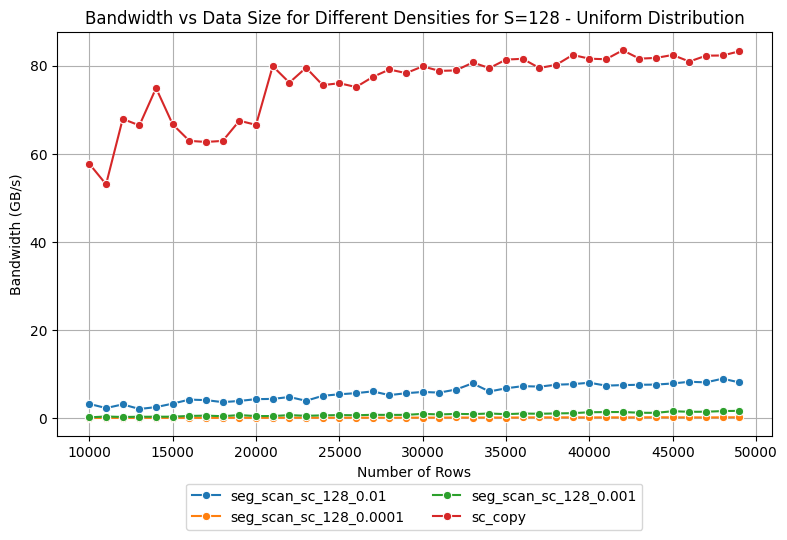

In [8]:

plt.figure(figsize=(8, 5))
sns.lineplot(x='nrow', y='bandwidth_gbps', hue='operator', data=tot_dataframe, marker='o')

plt.xlabel('Number of Rows')
plt.ylabel('Bandwidth (GB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=128 - Uniform Distribution')
plt.tight_layout()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.grid(True)
filename = "segmented_scan_uniform.pdf"
plt.savefig(filename, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

pd.set_option('display.max_rows', 1000)

copy_df = pd.concat(map(pd.read_csv, glob(join('..', f"*copy*.csv"))))

copy_df['mem_bytes'] = (copy_df['size'] * (2 ))  + copy_df['size'] * 2
copy_df['bandwidth_gbps'] = (copy_df['mem_bytes']) / (copy_df['time_us']*1000) #GB/s
copy_df["operator"] = "sc_copy"

tot_dataframe =  pd.concat(map(pd.read_csv, glob(join('..', f"*PowerLaw*seg_scan_sc*.csv"))))
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4
tot_dataframe['bandwidth_gbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']*1000) #GB/s
tot_dataframe["density"] = ["%s" % x for x in tot_dataframe["density"]]
tot_dataframe = pd.concat([tot_dataframe,copy_df])

KeyError: 'size'

In [4]:

plt.figure(figsize=(8, 5))
sns.lineplot(x='nrow', y='bandwidth_gbps', hue='operator', data=tot_dataframe, marker='o')

plt.xlabel('Number of Rows')
plt.ylabel('Bandwidth (GB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=128 - Power Law Distribution')
plt.tight_layout()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.grid(True)
filename = "segmented_scan_powerlaw.pdf"
plt.savefig(filename, bbox_inches='tight')
plt.show()


ValueError: Could not interpret value `nrow` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>